# Bayesian Active Learning

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cells to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml[opt] torch torchvision torchaudio transformers datasets[audio]

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

This tutorial illustrates how Bayesian active learning query strategies can be applied within ``scikit-activeml`` to an audio classification task. In particular, we demonstrate pool-based active learning on the AudioMNIST dataset, where raw audio signals are first transformed into fixed embeddings using a pretrained Wav2Vec 2.0 model. These embeddings serve as input to a lightweight classification head, enabling efficient training and uncertainty estimation.

The main focus of this notebook is on **Bayesian active learning**, where epistemic uncertainty is approximated via Monte Carlo (MC) dropout and exploited by Bayesian query strategies available in ``scikit-activeml``, such as uncertainty-based or information-theoretic selection methods. By repeatedly querying the most informative audio samples for annotation, we aim to achieve strong predictive performance with a minimal labeling budget.

From a structural perspective, this tutorial closely follows the general workflow used in other deep active learning examples in ``scikit-activeml``:
1. dataset preparation and embedding extraction,
2. definition of a neural network ``pytorch`` module,
3. specification of Bayesian query strategies,
4. execution of an active learning loop with iterative querying and retraining.

Compared to image-based tutorials (e.g., those using frozen Vision Transformers), this notebook highlights how the same active learning principles transfer seamlessly to the audio domain. In doing so, it demonstrates that ``scikit-activeml`` can be combined with modern audio foundation models for speech processing to perform Bayesian active learning on real-world audio data.

In [2]:
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt
import torch
import warnings

from copy import deepcopy
from functools import lru_cache
from datasets import load_dataset, Audio
from multiprocess import set_start_method
from skactiveml.classifier import SkorchClassifier
from skactiveml.pool import (
    RandomSampling,
    UncertaintySampling,
    GreedyBALD,
    BatchBALD,
    QueryByCommittee,
    SubSamplingWrapper,
)
from skactiveml.utils import call_func
from skorch.callbacks import LRScheduler
from torch import nn
from torch.nn import functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from transformers import AutoFeatureExtractor

set_start_method("spawn", force=True)
warnings.filterwarnings("ignore")
mlp.rcParams["figure.facecolor"] = "white"
device = "cuda" if torch.cuda.is_available() else "cpu"
random_state = 0
missing_label = -1

## Embed AudioMNIST with Wac2Vec
We turn the raw AudioMNIST waveforms into fixed-size feature vectors using a pretrained Wav2Vec 2.0 model. We first resample all audio clips to the sampling rate expected by Wav2Vec, then use the corresponding feature extractor and model to obtain hidden representations. For each recording, we pool the hidden states into a single embedding vector (e.g., by averaging over time). These embeddings are stored as our feature matrix ``X``, while the spoken digit labels form ``y``. All subsequent active learning steps in ``scikit-activeml`` operate only on these precomputed Wav2Vec embeddings, without re-running the foundation model.

In [3]:
# Spoken digit dataset: 0–9, circa 30k clips of 60 speakers
ds = load_dataset("gilkeyio/AudioMNIST")

# Use provided train / test splits
train_ds = ds["train"]
test_ds = ds["test"]

# Ensure a fixed sampling rate for all audio (16 kHz for Wav2Vec2)
train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16_000))
test_ds = test_ds.cast_column("audio", Audio(sampling_rate=16_000))

# Load the processor for the audio foundation model (wav2vec2-base).
model_name = "facebook/wav2vec2-base"
processor = AutoFeatureExtractor.from_pretrained(model_name)


# Load once per worker to avoid serializing the parametrized model.
@lru_cache(maxsize=1)
def get_embedding_model(model_name, device):
    import warnings
    from transformers import Wav2Vec2Model

    warnings.filterwarnings("ignore")
    return Wav2Vec2Model.from_pretrained(model_name).to(device).eval()


def embed(
    batch,
    processor,
    device,
    model_name,
    get_embedding_model=get_embedding_model,
):
    import torch

    model = get_embedding_model(model_name, device)
    audio_arrays = [a["array"] for a in batch["audio"]]
    sampling_rate = batch["audio"][0]["sampling_rate"]

    inputs = processor(
        audio_arrays,
        sampling_rate=sampling_rate,
        return_tensors="pt",
        padding=True,
    ).to(device)

    with torch.no_grad():
        out = model(**inputs).last_hidden_state
        # Global mean pooling
        emb = out.mean(dim=1)

    return {"emb": emb.cpu().numpy()}


embed_kwargs = {
    "processor": processor,
    "model_name": model_name,
    "device": device,
}
train_ds = train_ds.map(
    embed,
    batched=True,
    batch_size=2,
    num_proc=2,
    fn_kwargs=embed_kwargs,
    remove_columns=["audio"],
)
test_ds = test_ds.map(
    embed,
    batched=True,
    batch_size=2,
    num_proc=2,
    fn_kwargs=embed_kwargs,
    remove_columns=["audio"],
)

# Digit labels: 0-9
label_col = "digit"

# Create numpy arrays
X_pool = np.stack(train_ds["emb"], dtype=np.float32)
y_pool = np.array(train_ds[label_col], dtype=np.int64)
X_test = np.stack(test_ds["emb"], dtype=np.float32)
y_test = np.array(test_ds[label_col], dtype=np.int64)
n_features = X_pool.shape[1]
classes = np.unique(y_pool)

Map (num_proc=2):   0%|          | 0/24000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/6000 [00:00<?, ? examples/s]

## PyTorch Module with Monte-Carlo Dropout

This following module assumes that the inputs are fixed embeddings produced by a (possibly frozen) foundational model. During training, dropout is applied directly to the input embeddings with a different random mask for each forward pass. During evaluation, if Monte Carlo (MC) dropout is enabled, a fixed set of dropout masks is sampled once and reused across multiple forward calls, so that each MC sample can be interpreted as a persistent ensemble member.

In [4]:
class ClassificationModule(nn.Module):
    """MLP classifier with optional MC dropout on input embeddings.

    Parameters
    ----------
    n_features : int
        Dimensionality of the input embeddings.
    n_classes : int
        Number of output classes.
    n_hidden_units : int
        Number of hidden units in the hidden layer.
    mc_dropout_p : float, default=0.5
        Dropout probability applied to the input embeddings. Used during
        training for regularization and, if MC sampling is enabled, during
        evaluation by means of fixed dropout masks.
    n_mc_samples : int, default=0
        Number of MC dropout samples in evaluation mode. If
        ``n_mc_samples <= 1`` or ``mc_dropout_p <= 0``, evaluation is
        deterministic and no MC statistics are returned.
    """
    def __init__(
        self,
        n_features,
        n_classes,
        n_hidden_units,
        mc_dropout_p=0.5,
        n_mc_samples=0,
    ):
        super().__init__()
        self.linear_1 = nn.Linear(n_features, n_hidden_units)
        self.linear_2 = nn.Linear(n_hidden_units, n_classes)
        self.activation = nn.ReLU()

        self.mc_dropout_p = mc_dropout_p
        self.n_mc_samples = n_mc_samples

        # Fixed dropout masks (n_mc_samples, n_features), used only in eval.
        self.register_buffer("mc_masks", None)

    def _mc_enabled(self):
        """Return True if MC dropout is configured to be active in eval."""
        return (
            not self.training
            and self.n_mc_samples is not None
            and self.n_mc_samples > 1
            and self.mc_dropout_p > 0.0
        )

    def _init_mc_masks(self, device, n_features):
        """Sample fixed dropout masks if MC is enabled and masks are missing.
        """
        if not self._mc_enabled():
            self.mc_masks = None
            return

        expected_shape = (self.n_mc_samples, n_features)
        if self.mc_masks is not None and self.mc_masks.shape == expected_shape:
            return

        keep_prob = 1.0 - self.mc_dropout_p
        mask = torch.empty(
            *expected_shape,
            device=device,
        ).bernoulli_(keep_prob) / keep_prob
        self.mc_masks = mask

    def _forward_head(self, x):
        """Shared MLP head.

        Parameters
        ----------
        x : torch.Tensor of shape (batch_size, n_features)
            Input embeddings or masked embeddings.

        Returns
        -------
        logits : torch.Tensor of shape (batch_size, n_classes)
            Class logits.
        """
        hidden = self.activation(self.linear_1(x))
        logits = self.linear_2(hidden)
        return logits

    def forward(self, x):
        """Compute logits and, in evaluation mode, optional MC statistics.

        Parameters
        ----------
        x : torch.Tensor of shape (n_samples, n_features)
            Input embeddings.

        Returns
        -------
        Training mode (``self.training is True``)
            logits : torch.Tensor of shape (n_samples, n_classes)
                Class logits from a single forward pass with standard dropout
                on the input embeddings.

        Evaluation mode, MC disabled
            logits : torch.Tensor of shape (n_samples, n_classes)
                Deterministic class logits from a single forward pass without
                dropout on the input embeddings.

        Evaluation mode, MC enabled
            logits_mean : torch.Tensor of shape (n_samples, n_classes)
                Mean logits over MC ensemble members, i.e.
                ``logits_mc.mean(axis=1)``.
            logits_mc : torch.Tensor of shape (n_samples, n_mc_samples, n_classes)
                Logits for each MC ensemble member, obtained by applying the
                fixed dropout masks to the input embeddings.
        """
        n_samples, n_features = x.shape

        # Training: standard dropout with varying masks
        if self.training:
            if self.mc_dropout_p > 0.0:
                x_dropped = F.dropout(x, p=self.mc_dropout_p, training=True)
            else:
                x_dropped = x
            logits = self._forward_head(x_dropped)
            return logits

        # Evaluation, MC disabled: deterministic forward without dropout
        if not self._mc_enabled():
            logits = self._forward_head(x)
            return logits

        # Evaluation, MC enabled: use fixed masks as ensemble members
        self._init_mc_masks(x.device, n_features)
        if self.mc_masks is None:
            # Safety fallback: behave as if MC were disabled
            logits = self._forward_head(x)
            return logits

        # x: (B, F) -> (B, 1, F)
        x_expanded = x.unsqueeze(1)
        # mc_masks: (S, F) -> (1, S, F)
        mc_masks_expanded = self.mc_masks.unsqueeze(0)

        # Apply fixed masks: (B, S, F)
        x_masked = x_expanded * mc_masks_expanded

        # Flatten batch and sample dims for shared head: (B * S, F)
        x_masked_flat = x_masked.reshape(-1, n_features)
        logits_mc_flat = self._forward_head(x_masked_flat)
        # Reshape back to (B, S, C)
        logits_mc = logits_mc_flat.view(n_samples, self.n_mc_samples, -1)

        logits_mean = logits_mc.mean(dim=1)
        return logits_mean, logits_mc

## Bayesian Skorch Classifier

In this step, we define a ``BayesianSkorchClassifier`` that extends ``SkorchClassifier`` with a sample_proba method, which returns the class probabilities predicted by each individual ensemble member (e.g., MC dropout samples). We then initialize the classifier with the ClassificationModule as ``pytorch`` module, configure MC dropout via ``n_mc_samples`` and ``mc_dropout_p``, and set standard training hyperparameters such as optimizer, learning rate, batch size, and learning rate scheduler.

In [5]:
class BayesianSkorchClassifier(SkorchClassifier):
    """
    Helper class implement a function returning the predicted class probabilities
    predicted by the individual ensemble members.
    """

    def sample_proba(self, X):
        """Returns the predicted class probabilities predicted by
         the individual ensemble members.

         Parameters
         ----------
         X : numpy.ndarray of shape (n_samples, n_features)
            Test samples

        Returns
        -------
        P_mc : numpy.ndarray of shape (n_members, n_samples, n_classes)
            Probabilities predicted by the individual ensemble members.
        """
        # Swap axes to have desired shape.
        P_mc = self.predict_proba(X, extra_outputs=["probas_mc"])[-1].swapaxes(0, 1)
        return P_mc


# Initialize classifier including training hyperparameters.
clf_init = BayesianSkorchClassifier(
    module=ClassificationModule,
    criterion=nn.CrossEntropyLoss,
    forward_outputs={"proba": (0, nn.Softmax(dim=-1)), "probas_mc": (1, nn.Softmax(dim=-1))},
    neural_net_param_dict={
        # Module-related parameters.
        "module__n_features": n_features,
        "module__n_hidden_units": 128,
        "module__n_classes": len(classes),
        "module__n_mc_samples": 10,
        "module__mc_dropout_p": 0.2,
        # Optimizer-related parameters.
        "max_epochs": 50,
        "batch_size": 16,
        "lr": 0.01,
        "optimizer": torch.optim.RAdam,
        "callbacks": [
            ("lr_scheduler", LRScheduler(policy=CosineAnnealingLR, T_max=50))
        ],
        # General parameters.
        "verbose": 0,
        "device": device,
        "train_split": False,
        "iterator_train__shuffle": True,
    },
    classes=classes,
    missing_label=missing_label,
).initialize()

## Active Classification
For our classifier, we evaluate five different query strategies regarding their sample selection. For this purpose, we start with ``n_init_labels=64`` initial labels selected via random sampling and make ``n_cycles=10`` iterations of an active learning cycle with ``batch_size=32``.

In [6]:
# Define setup.
n_cycles = 10
batch_size = 32
n_sub_set = 5000
n_init_labels = 64
qs_dict = {
    "RandomSampling": RandomSampling(
        random_state=random_state, missing_label=missing_label
    ),
    "UncertaintySampling": UncertaintySampling(
        random_state=random_state,
        missing_label=missing_label,
        method="margin_sampling",
    ),
    "QBC": QueryByCommittee(
        method="vote_entropy",
        sample_predictions_method_name="sample_proba",
        random_state=random_state,
        missing_label=missing_label,
    ),
    "GreedyBALD": GreedyBALD(
        sample_predictions_method_name="sample_proba",
        random_state=random_state,
        missing_label=missing_label,
    ),
    "BatchBALD": BatchBALD(
        sample_predictions_method_name="sample_proba",
        random_state=random_state,
        missing_label=missing_label,
    ),
}
acc_dict = {key: np.zeros(n_cycles + 1) for key in qs_dict}


# Perform active learning with each query strategy.
for qs_name, qs in qs_dict.items():
    print(f"Execute active learning using {qs_name}.")
    # Set seed and copy classifier for consistent initialization.
    torch.manual_seed(random_state)
    torch.cuda.manual_seed(random_state)
    clf = deepcopy(clf_init)

    # Wrapper to subsample unlabeled samples.
    qs = SubSamplingWrapper(
        query_strategy=qs,
        max_candidates=n_sub_set,
        exclude_non_subsample=True,
        random_state=random_state,
        missing_label=missing_label,
    )
    qs_init = RandomSampling(random_state=random_state, missing_label=missing_label)

    # Create array with 64 initial labels.
    y = np.full_like(y_pool, fill_value=missing_label, dtype=np.int64)
    init_indices = np.random.RandomState(0).choice(
        np.arange(len(y)), size=n_init_labels, replace=False
    )
    y[init_indices] = y_pool[init_indices]

    # Execute active learning cycle.
    for c in tqdm(range(n_cycles)):
        # Fit and evaluate clf.
        acc = clf.fit(X_pool, y).score(X_test, y_test)
        acc_dict[qs_name][c] = acc

        # Select and update training data.
        query_idx = call_func(
            qs.query,
            X=X_pool,
            y=y,
            clf=clf,
            fit_clf=False,
            ensemble=clf,
            fit_ensemble=False,
            batch_size=batch_size,
        )
        y[query_idx] = y_pool[query_idx]

    # Fit and evaluate clf.
    clf.fit(X_pool, y)
    acc_dict[qs_name][n_cycles] = clf.score(X_test, y_test)

Execute active learning using RandomSampling.


100%|██████████| 10/10 [00:06<00:00,  1.54it/s]


Execute active learning using UncertaintySampling.


100%|██████████| 10/10 [00:07<00:00,  1.38it/s]


Execute active learning using QBC.


100%|██████████| 10/10 [00:07<00:00,  1.38it/s]


Execute active learning using GreedyBALD.


100%|██████████| 10/10 [00:07<00:00,  1.36it/s]


Execute active learning using BatchBALD.


100%|██████████| 10/10 [00:12<00:00,  1.22s/it]


## Visualize Results
In the following, we plot the obtained learning curves including the area under learning curve (AULC) scores per query strategy.

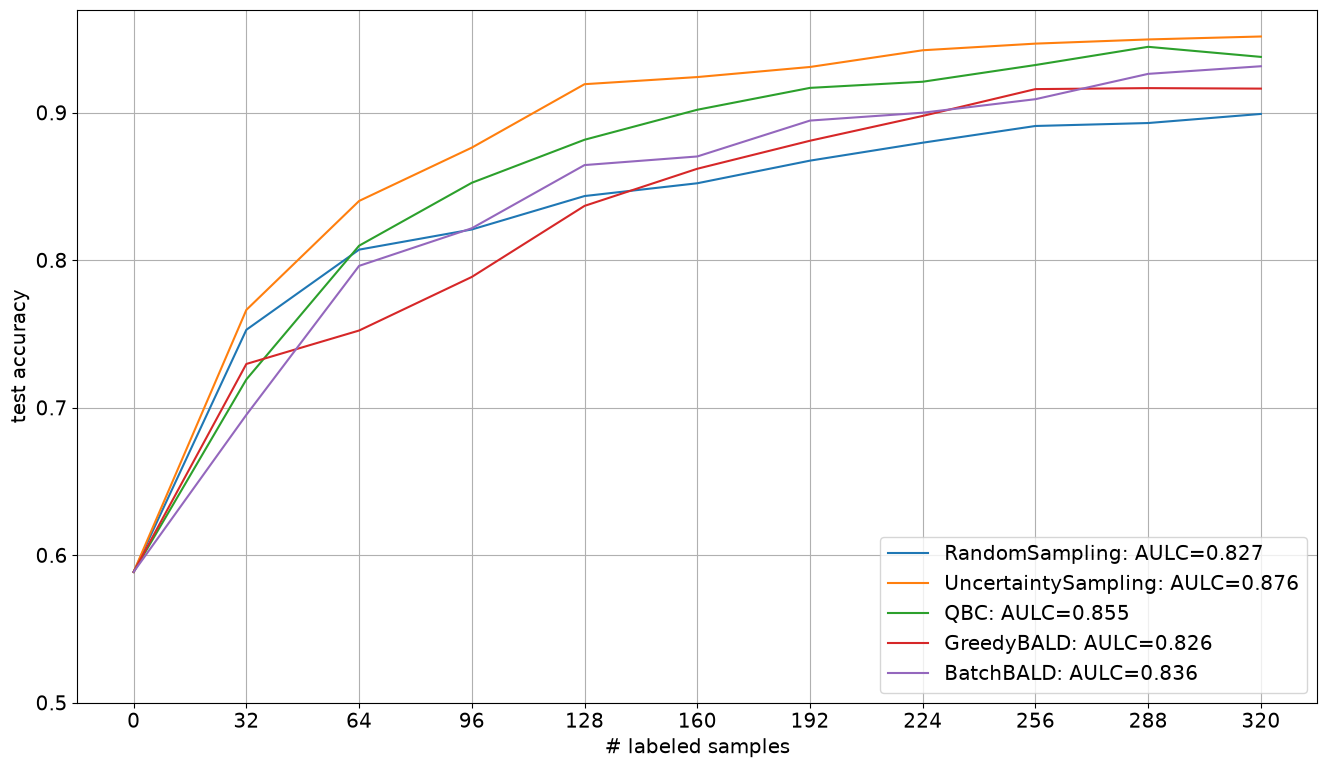

In [7]:
cycles = np.arange(n_cycles + 1, dtype=int)
plt.figure(figsize=(16, 9))
for qs_name, acc in acc_dict.items():
    plt.plot(
        cycles * batch_size,
        acc,
        label=f"{qs_name}: AULC={round(acc.mean(), 3)}",
    )
plt.xticks(cycles * batch_size, fontsize="x-large")
plt.yticks(np.arange(0.5, 1.0, 0.1), fontsize="x-large")
plt.grid()
plt.xlabel("# labeled samples", fontsize="x-large")
plt.ylabel("test accuracy", fontsize="x-large")
plt.legend(loc="lower right", fontsize="x-large")
plt.show()#%%
